# PubMedQA Baseline — Does Retrieved Context Help?

### Context Matters: Evaluating Diversity-Aware Retrieval for RAG

This notebook evaluates the **non-diversified PubMedQA baseline**.

We ask one simple question:

> **Does giving an LLM retrieved evidence improve its answer compared with answering the same question without retrieved evidence?**

We evaluate:

- **1,000 PubMedQA questions**
- **4 retrievers:** BM25, DPR, Contriever, ColBERTv2
- **3 generators:** Llama 3.3 70B, Gemma 4 26B, Qwen3.6 36B
- **Top-20 retrieval candidates**
- **Top-5 passages given to the LLM**
- **15,000 governed generations**

The notebook first measures **retrieval quality** and then checks whether the retrieved evidence improves **PubMedQA decision accuracy**.

All expensive retrieval and LLM generation has already been completed.

**Running this notebook does not call an LLM API or regenerate experimental results.**

## What This Notebook Shows

This notebook follows the PubMedQA baseline experiment from retrieval to final answer quality.

We answer four questions:

1. **How well does each retriever find relevant evidence?**
2. **How were the LLM answers generated?**
3. **Does retrieved context improve answer accuracy compared with no context?**
4. **Does stronger retrieval lead to better final answers?**

The notebook is organized as:

**Dataset → Retrieval → Generation → Correctness → Context Effect → Main Findings**

All reported results come from saved experimental artifacts produced by the governed Sprint 3 pipeline.

In [1]:
from pathlib import Path
import sys
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Find the repository root
# ------------------------------------------------------------

def find_project_root(start: Path) -> Path:
    """
    Find the Context Matters repository without assuming
    a fixed /workspace path.
    """
    start = start.resolve()

    candidates = [start, *start.parents]

    for candidate in candidates:
        if (
            (candidate / "src").exists()
            and (candidate / "configs" / "sprint3").exists()
            and (candidate / "artifacts").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not find the Context Matters project root."
    )


ROOT = find_project_root(Path.cwd())
SRC = ROOT / "src"

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))


# ------------------------------------------------------------
# Important project locations
# ------------------------------------------------------------

RESULTS_DIR = ROOT / "results"
SPRINT3_RESULTS_DIR = RESULTS_DIR / "sprint3"

GENERATION_DIR = (
    SPRINT3_RESULTS_DIR
    / "raw"
    / "pubmedqa"
    / "generation"
)

ANALYSIS_DIR = (
    SPRINT3_RESULTS_DIR
    / "analysis"
    / "pubmedqa_baseline"
)


# ------------------------------------------------------------
# Basic environment check
# ------------------------------------------------------------

required_paths = {
    "Source code": ROOT / "src",
    "Sprint 3 config": ROOT / "configs" / "sprint3",
    "Artifacts": ROOT / "artifacts",
    "Generation results": GENERATION_DIR,
}

missing = [
    name
    for name, path in required_paths.items()
    if not path.exists()
]

if missing:
    raise FileNotFoundError(
        "Missing required project resources: "
        + ", ".join(missing)
    )


print("Environment check: PASS")
print(f"Project root: {ROOT}")
print(f"Python: {platform.python_version()}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print("LLM/API calls made by this notebook setup: 0")

Environment check: PASS
Project root: /workspace/context-matters-rag-sprint3-current
Python: 3.12.3
Pandas: 3.0.5
NumPy: 2.1.2
LLM/API calls made by this notebook setup: 0


## Dataset — PubMedQA

We use the **PubMedQA PQA-L labeled dataset** as the baseline evaluation dataset.

The experiment contains:

- **1,000 questions**
- **3,358 corpus passages**
- one gold decision for each question: **yes**, **no**, or **maybe**

For each question, the retrievers first produce the **Top-20 candidate passages**.
The baseline RAG system then gives the **Top-5 passages** to the language model.

### What counts as a correct answer?

The primary PubMedQA correctness metric is **decision accuracy**.

A generated answer is correct when its parsed:

`Decision: yes | no | maybe`

matches the dataset's gold `final_decision`.

The generated explanation is **not used to calculate decision accuracy**. It is preserved for later analyses such as faithfulness and answer-content change.

### Role in Sprint 3

PubMedQA is used as a **controlled baseline and replication dataset**.

Its results help us understand the basic effect of retrieved context before evaluating diversification on the protected HotpotQA and ASQA experiments.

In [2]:
from datasets import load_dataset, disable_progress_bar

from scripts.build_corpus_manifests import (
    PUBMEDQA_SOURCE,
    PUBMEDQA_CONFIG,
    PUBMEDQA_REVISION,
    PUBMEDQA_SPLIT,
    load_validated_pubmedqa_runtime_corpus,
)


disable_progress_bar()


# ------------------------------------------------------------
# Load the exact frozen PubMedQA revision
# ------------------------------------------------------------

dataset = load_dataset(
    PUBMEDQA_SOURCE,
    PUBMEDQA_CONFIG,
    split=PUBMEDQA_SPLIT,
    revision=PUBMEDQA_REVISION,
    download_mode="reuse_dataset_if_exists",
)

dataset_rows = tuple(dataset)


# ------------------------------------------------------------
# Validate against the committed Sprint 3 manifests
# ------------------------------------------------------------

runtime_corpus = load_validated_pubmedqa_runtime_corpus(
    dataset_rows
)

sample_manifest = runtime_corpus.sample_manifest
corpus_manifest = runtime_corpus.corpus_manifest


# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

assert len(dataset_rows) == 1000
assert len(sample_manifest.entries) == 1000
assert corpus_manifest.document_count == 3358

gold_decisions = pd.Series(
    [
        row["final_decision"]
        for row in dataset_rows
    ],
    name="Gold decision",
)

gold_counts = (
    gold_decisions
    .value_counts()
    .reindex(
        ["yes", "no", "maybe"]
    )
)


assert gold_counts.sum() == 1000


# ------------------------------------------------------------
# Clear professor-facing output
# ------------------------------------------------------------

print("PubMedQA dataset validation: PASS")
print()
print(f"Questions:       {len(dataset_rows):,}")
print(f"Corpus passages: {corpus_manifest.document_count:,}")

print()
print("Gold decision distribution:")
display(
    gold_counts
    .rename_axis("Decision")
    .reset_index(name="Questions")
)

print(
    "Frozen source revision:",
    PUBMEDQA_REVISION
)

print("LLM/API calls made by this cell: 0")

PubMedQA dataset validation: PASS

Questions:       1,000
Corpus passages: 3,358

Gold decision distribution:


,Decision,Questions
0,yes,552
1,no,338
2,maybe,110


Frozen source revision: 9001f2853fb87cab8d220904e0de81ac6973b318
LLM/API calls made by this cell: 0


## Experimental Design

We compare three language models under the same experimental settings.

| Component | Setting |
|---|---|
| Questions | 1,000 PubMedQA questions |
| Generators | Llama 3.3 70B, Gemma 4 26B, Qwen3.6 36B |
| Retrievers | BM25, DPR, Contriever, ColBERTv2 |
| Candidate pool | Top-20 passages |
| Context given to LLM | Top-5 passages |
| Baseline | Without retrieved context |

Each language model is evaluated in five conditions:

1. **Without context**
2. **BM25 context**
3. **DPR context**
4. **Contriever context**
5. **ColBERTv2 context**

### Total generations

**3 models × 5 conditions × 1,000 questions = 15,000 answers**

All conditions use the same questions, prompt format, decoding settings, and evaluation rules.

This lets us measure how retrieved context changes answer quality while keeping the rest of the experiment fixed.

## Generation Settings

All three language models use the same generation setup.

| Setting | Value |
|---|---|
| Temperature | 0 |
| Maximum output length | 256 tokens |
| Generation mode | Direct / non-thinking |
| Output format | `Decision: yes / no / maybe` + explanation |
| Context size | Top-5 retrieved passages |
| Repetitions | 1 canonical generation per condition |
| Infrastructure retries | Up to 3 attempts |
| Content retries | None |

The same prompt and decoding settings are used across all models and retrievers.

If a model output cannot be parsed correctly, it is recorded as a failure rather than being regenerated until a desired answer appears.

This keeps the comparison consistent and prevents result selection after generation.

In [3]:
import json


# ------------------------------------------------------------
# Frozen model and repeatability artifacts
# ------------------------------------------------------------

MODEL_BINDINGS_PATH = (
    ROOT
    / "configs"
    / "sprint3"
    / "maki_model_bindings_v7.json"
)

REPEATABILITY_GATE_PATH = (
    ROOT
    / "artifacts"
    / "generation_repeatability"
    / "repeatability_gate_v6.json"
)


assert MODEL_BINDINGS_PATH.exists()
assert REPEATABILITY_GATE_PATH.exists()


with MODEL_BINDINGS_PATH.open(
    "r",
    encoding="utf-8",
) as f:
    model_bindings = json.load(f)


with REPEATABILITY_GATE_PATH.open(
    "r",
    encoding="utf-8",
) as f:
    repeatability_gate = json.load(f)


# ------------------------------------------------------------
# Frozen logical model IDs
# ------------------------------------------------------------

MODEL_ORDER = [
    "llama-3.3-70b",
    "gemma4-26b",
    "ministral-3-14b",
]

MODEL_DISPLAY = {
    "llama-3.3-70b": "Llama 3.3 70B",
    "gemma4-26b": "Gemma 4 26B",
    "ministral-3-14b": "Qwen3.6 36B",
}


bindings = model_bindings["models"]

gate_models = {
    row["logical_model_id"]: row
    for row in repeatability_gate[
        "scientific_payload"
    ]["models"]
}


# ------------------------------------------------------------
# Validate every admitted generator
# ------------------------------------------------------------

rows = []

for logical_id in MODEL_ORDER:

    binding = bindings[logical_id]
    gate = gate_models[logical_id]

    assert binding[
        "direct_mode_status"
    ] == "SUPPORTED_AND_ENABLED"

    assert gate["passed"] is True
    assert gate["prompt_count"] == 20
    assert gate["identical_prompt_count"] >= 19

    rows.append(
        {
            "Generator": MODEL_DISPLAY[
                logical_id
            ],
            "Runtime model": binding[
                "physical_model_id"
            ],
            "Direct mode": "Enabled",
            "Repeatability": (
                f"{gate['identical_prompt_count']}"
                f"/{gate['prompt_count']} prompts"
            ),
            "Admitted": "Yes",
        }
    )


model_validation = pd.DataFrame(rows)


# Qwen occupies the frozen third model slot.
assert (
    bindings["ministral-3-14b"][
        "physical_model_id"
    ]
    == "qwen3.6-36b"
)

assert repeatability_gate[
    "scientific_payload"
]["all_primary_models_passed"] is True


print(
    "Generator validation: PASS"
)

display(model_validation)

print()
print(
    "All three generators passed "
    "the repeatability admission check."
)

print(
    "LLM/API calls made by this cell: 0"
)

Generator validation: PASS


,Generator,Runtime model,Direct mode,Repeatability,Admitted
0,Llama 3.3 70B,llama-3.3-70b,Enabled,20/20 prompts,Yes
1,Gemma 4 26B,gemma4-26b,Enabled,20/20 prompts,Yes
2,Qwen3.6 36B,qwen3.6-36b,Enabled,20/20 prompts,Yes



All three generators passed the repeatability admission check.
LLM/API calls made by this cell: 0


## Retrieval Evaluation

Before looking at LLM answers, we first check how well each retriever finds relevant PubMedQA evidence.

We report three retrieval metrics:

| Metric | What it tells us |
|---|---|
| **Recall@5** | How much relevant evidence appears in the final Top-5 passages |
| **MRR@5** | How early the first relevant passage appears in the Top-5 |
| **Recall@20** | How much relevant evidence is available in the Top-20 candidate pool |

Higher values are better.

The four retrievers are evaluated on the same 1,000 PubMedQA questions.

These retrieval results come from the historical Sprint 1 baseline and are kept separate from the new Sprint 3 generation analysis.

In [4]:
# ------------------------------------------------------------
# Historical PubMedQA retrieval evidence
# ------------------------------------------------------------

RETRIEVAL_DIR = (
    ROOT
    / "results"
    / "sprint1"
    / "pubmedqa"
)

RETRIEVAL_SUMMARY_PATH = (
    RETRIEVAL_DIR
    / "retrieval_summary.csv"
)

RETRIEVAL_PER_QUERY_PATH = (
    RETRIEVAL_DIR
    / "retrieval_per_query.csv"
)


assert RETRIEVAL_SUMMARY_PATH.exists()
assert RETRIEVAL_PER_QUERY_PATH.exists()


retrieval_summary = pd.read_csv(
    RETRIEVAL_SUMMARY_PATH
)

retrieval_per_query = pd.read_csv(
    RETRIEVAL_PER_QUERY_PATH
)


# ------------------------------------------------------------
# Validate the saved evidence
# ------------------------------------------------------------

EXPECTED_RETRIEVERS = [
    "bm25",
    "dpr",
    "contriever",
    "colbertv2",
]

RETRIEVER_DISPLAY = {
    "bm25": "BM25",
    "dpr": "DPR",
    "contriever": "Contriever",
    "colbertv2": "ColBERTv2",
}


assert set(
    retrieval_summary["retriever"]
) == set(EXPECTED_RETRIEVERS)

assert (
    retrieval_summary["questions"]
    == 1000
).all()

assert len(
    retrieval_per_query
) == 4000

assert (
    retrieval_per_query
    .groupby("retriever")
    .size()
    .eq(1000)
    .all()
)


# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

retrieval_table = (
    retrieval_summary
    .assign(
        Retriever=lambda df:
            df["retriever"].map(
                RETRIEVER_DISPLAY
            )
    )
    .set_index("retriever")
    .loc[EXPECTED_RETRIEVERS]
    .reset_index(drop=True)
    [
        [
            "Retriever",
            "recall_at_5",
            "mrr_at_5",
            "candidate_recall_at_20",
        ]
    ]
    .rename(
        columns={
            "recall_at_5": "Recall@5",
            "mrr_at_5": "MRR@5",
            "candidate_recall_at_20": "Recall@20",
        }
    )
)


print(
    "Historical retrieval evidence: PASS"
)

display(
    retrieval_table.style.format(
        {
            "Recall@5": "{:.3f}",
            "MRR@5": "{:.3f}",
            "Recall@20": "{:.3f}",
        }
    )
)

print()
print(
    "Questions per retriever: 1,000"
)

print(
    "LLM/API calls made by this cell: 0"
)

Historical retrieval evidence: PASS


,Retriever,Recall@5,MRR@5,Recall@20
0,BM25,0.599,0.912,0.702
1,DPR,0.325,0.579,0.465
2,Contriever,0.740,0.972,0.837
3,ColBERTv2,0.738,0.976,0.825



Questions per retriever: 1,000
LLM/API calls made by this cell: 0


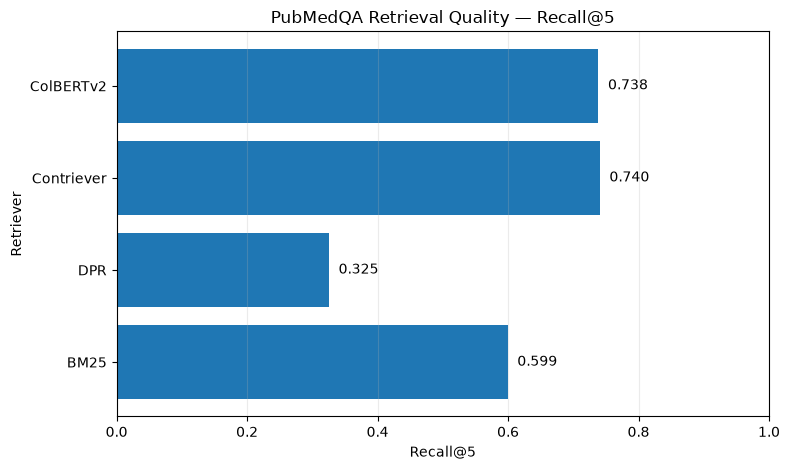

In [5]:
# ------------------------------------------------------------
# Retrieval quality figure
# ------------------------------------------------------------

plot_df = (
    retrieval_table[
        ["Retriever", "Recall@5"]
    ]
    .copy()
)


fig, ax = plt.subplots(
    figsize=(8, 4.8)
)


bars = ax.barh(
    plot_df["Retriever"],
    plot_df["Recall@5"],
)


# Show the exact value beside each bar
for bar, value in zip(
    bars,
    plot_df["Recall@5"],
):

    ax.text(
        value + 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=10,
    )


ax.set_xlim(0, 1)

ax.set_xlabel(
    "Recall@5"
)

ax.set_ylabel(
    "Retriever"
)

ax.set_title(
    "PubMedQA Retrieval Quality — Recall@5"
)

ax.grid(
    axis="x",
    alpha=0.25,
)

fig.tight_layout()

plt.show()

### Retrieval Result

Contriever and ColBERTv2 retrieve the strongest evidence in the Top-5 passages, with Recall@5 around **0.74**.

BM25 performs moderately well at **0.599**, while DPR has the lowest Recall@5 at **0.325**.

This matters because the language model can only use evidence that the retriever successfully provides.

The next step is to check whether these differences in retrieval quality also lead to differences in final answer accuracy.

In [6]:
from run_registry import read_registry


# ------------------------------------------------------------
# Governed run registry
# ------------------------------------------------------------

REGISTRY_PATH = (
    ROOT
    / "artifacts"
    / "run_registry"
    / "run_registry_v1.jsonl"
)

EVIDENCE_AUTHORITY_PATH = (
    ROOT
    / "artifacts"
    / "run_registry"
    / "evidence_manifest_authority_v1.json"
)


registry_records = read_registry(
    REGISTRY_PATH,
    evidence_authority_path=EVIDENCE_AUTHORITY_PATH,
)


# ------------------------------------------------------------
# Keep the final lifecycle record for each PubMedQA
# generation run
# ------------------------------------------------------------

final_by_run = {}

for record in registry_records:

    if (
        record["run_type"] == "GENERATION"
        and record["data"]["dataset"] == "pubmedqa"
    ):
        final_by_run[
            record["run_id"]
        ] = record


# ------------------------------------------------------------
# Baseline conditions only: no diversification
# ------------------------------------------------------------

def diversification_method(record):

    value = record.get(
        "diversification"
    )

    if isinstance(value, dict):
        return value.get(
            "method",
            "none",
        )

    return "none"


def condition_key(record):

    context_mode = record[
        "context_mode"
    ]

    if context_mode == "without_context":

        retriever = "shared"

    else:

        retriever = record[
            "retrieval"
        ]["retriever"]

    return (
        context_mode,
        retriever,
        record[
            "generation"
        ]["llm_logical_id"],
    )


baseline_runs = [
    record
    for record
    in final_by_run.values()
    if diversification_method(
        record
    ) == "none"
]


# ------------------------------------------------------------
# Clean completed runs
# ------------------------------------------------------------

canonical_runs = {}

excluded_infrastructure_runs = []


for record in baseline_runs:

    output = record["output"]
    status = record[
        "execution"
    ]["status"]

    if (
        status == "COMPLETE"
        and output[
            "expected_row_count"
        ] == 1000
        and output[
            "completed_row_count"
        ] == 1000
        and output[
            "failed_row_count"
        ] == 0
    ):

        key = condition_key(
            record
        )

        if key in canonical_runs:
            raise ValueError(
                "More than one clean run exists "
                f"for condition: {key}"
            )

        canonical_runs[
            key
        ] = record

    elif (
        output[
            "failed_row_count"
        ] > 0
    ):

        excluded_infrastructure_runs.append(
            record
        )


# ------------------------------------------------------------
# Expected 15-condition matrix
# ------------------------------------------------------------

expected_conditions = set()


for logical_id in MODEL_ORDER:

    expected_conditions.add(
        (
            "without_context",
            "shared",
            logical_id,
        )
    )

    for retriever in (
        "bm25",
        "dpr",
        "contriever",
        "colbertv2",
    ):

        expected_conditions.add(
            (
                "with_context",
                retriever,
                logical_id,
            )
        )


assert len(
    expected_conditions
) == 15

assert set(
    canonical_runs
) == expected_conditions


# ------------------------------------------------------------
# Professor-facing matrix
# ------------------------------------------------------------

condition_rows = []


for retriever in [
    "WITHOUT CONTEXT",
    "BM25",
    "DPR",
    "Contriever",
    "ColBERTv2",
]:

    row = {
        "Condition": retriever
    }

    for logical_id in MODEL_ORDER:

        if retriever == "WITHOUT CONTEXT":

            key = (
                "without_context",
                "shared",
                logical_id,
            )

        else:

            reverse_map = {
                "BM25": "bm25",
                "DPR": "dpr",
                "Contriever": "contriever",
                "ColBERTv2": "colbertv2",
            }

            key = (
                "with_context",
                reverse_map[
                    retriever
                ],
                logical_id,
            )

        row[
            MODEL_DISPLAY[
                logical_id
            ]
        ] = (
            "Complete"
            if key in canonical_runs
            else "Missing"
        )

    condition_rows.append(
        row
    )


generation_matrix = pd.DataFrame(
    condition_rows
)


print(
    "Generation block validation: PASS"
)

print()
print(
    f"Canonical conditions: "
    f"{len(canonical_runs)} / 15"
)

print(
    "Questions per condition: 1,000"
)

print(
    "Expected generations: 15,000"
)

print(
    "Excluded infrastructure-failed runs:",
    len(
        excluded_infrastructure_runs
    ),
)

print()

display(
    generation_matrix
)

print(
    "LLM/API calls made by this cell: 0"
)

Generation block validation: PASS

Canonical conditions: 15 / 15
Questions per condition: 1,000
Expected generations: 15,000
Excluded infrastructure-failed runs: 1



,Condition,Llama 3.3 70B,Gemma 4 26B,Qwen3.6 36B
0,WITHOUT CONTEXT,Complete,Complete,Complete
1,BM25,Complete,Complete,Complete
2,DPR,Complete,Complete,Complete
3,Contriever,Complete,Complete,Complete
4,ColBERTv2,Complete,Complete,Complete


LLM/API calls made by this cell: 0


In [7]:
from generation.artifacts import (
    read_generation_artifact,
)


# ------------------------------------------------------------
# Load every canonical generation artifact
# ------------------------------------------------------------

generation_rows = []


for (
    context_mode,
    retriever_key,
    logical_id,
), run_record in canonical_runs.items():

    output_dir = (
        ROOT
        / run_record[
            "output"
        ][
            "output_directory"
        ]
    )

    sample_files = sorted(
        output_dir.glob(
            "sample_*.json"
        )
    )

    assert len(
        sample_files
    ) == 1000


    for path in sample_files:

        artifact = (
            read_generation_artifact(
                path
            )
        )

        request = artifact[
            "request"
        ]

        observation = artifact[
            "observation"
        ]

        parsed_output = observation[
            "parsed_output"
        ]


        if context_mode == "without_context":

            condition_display = (
                "WITHOUT CONTEXT"
            )

        else:

            condition_display = (
                RETRIEVER_DISPLAY[
                    retriever_key
                ]
            )


        generation_rows.append(
            {
                "sample_id":
                    request[
                        "sample_id"
                    ],

                "condition":
                    condition_display,

                "context_mode":
                    context_mode,

                "retriever":
                    retriever_key,

                "llm_logical_id":
                    logical_id,

                "generator":
                    MODEL_DISPLAY[
                        logical_id
                    ],

                "status":
                    observation[
                        "status"
                    ],

                "decision":
                    (
                        None
                        if parsed_output
                        is None
                        else parsed_output[
                            "decision"
                        ]
                    ),

                "raw_content":
                    observation[
                        "raw_content"
                    ],

                "finish_reason":
                    observation[
                        "finish_reason"
                    ],

                "run_id":
                    request[
                        "run_id"
                    ],

                "generation_artifact_id":
                    artifact[
                        "generation_artifact_id"
                    ],
            }
        )


generation_df = pd.DataFrame(
    generation_rows
)


# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

assert len(
    generation_df
) == 15000

assert (
    generation_df[
        "generation_artifact_id"
    ]
    .nunique()
    == 15000
)

assert set(
    generation_df[
        "sample_id"
    ]
) == set(
    range(1000)
)


condition_counts = (
    generation_df
    .groupby(
        [
            "generator",
            "condition",
        ]
    )
    .size()
)

assert (
    condition_counts
    == 1000
).all()


# ------------------------------------------------------------
# Status summary
# ------------------------------------------------------------

STATUS_ORDER = [
    "OK",
    "PARSE_FAILURE",
    "TRUNCATED",
    "REFUSAL",
    "ERROR",
]


status_totals = (
    generation_df[
        "status"
    ]
    .value_counts()
    .reindex(
        STATUS_ORDER,
        fill_value=0,
    )
)


status_table = (
    status_totals
    .rename_axis(
        "Status"
    )
    .reset_index(
        name="Outputs"
    )
)


print(
    "Generation artifact validation: PASS"
)

print()
print(
    f"Generation artifacts loaded: "
    f"{len(generation_df):,}"
)

print(
    f"Unique artifacts: "
    f"{generation_df['generation_artifact_id'].nunique():,}"
)

print()

display(
    status_table
)

print(
    "LLM/API calls made by this cell: 0"
)

Generation artifact validation: PASS

Generation artifacts loaded: 15,000
Unique artifacts: 15,000



,Status,Outputs
0,OK,14966
1,PARSE_FAILURE,33
2,TRUNCATED,1
3,REFUSAL,0
4,ERROR,0


LLM/API calls made by this cell: 0


### Generation Status Handling

Not every generated answer can be used for correctness evaluation.

We keep the original generation status instead of silently repairing failed outputs.

| Status | Meaning | Correctness treatment |
|---|---|---|
| **OK** | Valid parsed answer | Scored normally |
| **REFUSAL** | Model refused to answer | Scored as incorrect |
| **PARSE_FAILURE** | Required decision format could not be parsed | Not scored |
| **TRUNCATED** | Output ended because of the token limit | Not scored |
| **ERROR** | Infrastructure failure after all retries | Not scored |

For this experiment:

- **14,966** outputs are valid
- **33** are parse failures
- **1** is truncated
- **0** are refusals
- **0** are final infrastructure errors

Correctness is calculated only where the metric is valid. Missing or failed outputs are never converted to zero unless the protocol explicitly defines them as incorrect.

In [8]:
# ------------------------------------------------------------
# Gold PubMedQA decisions
# ------------------------------------------------------------

gold_df = pd.DataFrame(
    {
        "sample_id": range(
            len(dataset_rows)
        ),
        "gold_decision": [
            row["final_decision"]
            for row in dataset_rows
        ],
    }
)


assert len(gold_df) == 1000

assert set(
    gold_df["gold_decision"]
) == {
    "yes",
    "no",
    "maybe",
}


# ------------------------------------------------------------
# Join generations with gold labels
# ------------------------------------------------------------

generation_scored = (
    generation_df
    .merge(
        gold_df,
        on="sample_id",
        how="left",
        validate="many_to_one",
    )
)


assert (
    generation_scored[
        "gold_decision"
    ]
    .notna()
    .all()
)


# ------------------------------------------------------------
# Status-aware correctness
# ------------------------------------------------------------

def score_pubmedqa_row(row):

    if row["status"] == "OK":

        return float(
            row["decision"]
            == row[
                "gold_decision"
            ]
        )

    if row["status"] == "REFUSAL":

        return 0.0

    # PARSE_FAILURE, TRUNCATED and ERROR
    # are not measurable correctness values.
    return np.nan


generation_scored[
    "correct"
] = generation_scored.apply(
    score_pubmedqa_row,
    axis=1,
)


# ------------------------------------------------------------
# Ordered professor-facing summary
# ------------------------------------------------------------

CONDITION_ORDER = [
    "WITHOUT CONTEXT",
    "BM25",
    "DPR",
    "Contriever",
    "ColBERTv2",
]

GENERATOR_ORDER = [
    "Llama 3.3 70B",
    "Gemma 4 26B",
    "Qwen3.6 36B",
]


correctness_summary = (
    generation_scored
    .groupby(
        [
            "generator",
            "condition",
        ],
        as_index=False,
    )
    .agg(
        Expected_N=(
            "sample_id",
            "size",
        ),
        Measured_N=(
            "correct",
            "count",
        ),
        Accuracy=(
            "correct",
            "mean",
        ),
    )
)


correctness_summary[
    "generator"
] = pd.Categorical(
    correctness_summary[
        "generator"
    ],
    categories=GENERATOR_ORDER,
    ordered=True,
)

correctness_summary[
    "condition"
] = pd.Categorical(
    correctness_summary[
        "condition"
    ],
    categories=CONDITION_ORDER,
    ordered=True,
)


correctness_summary = (
    correctness_summary
    .sort_values(
        [
            "generator",
            "condition",
        ]
    )
    .reset_index(
        drop=True
    )
)


assert len(
    correctness_summary
) == 15

assert (
    correctness_summary[
        "Expected_N"
    ]
    == 1000
).all()


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display_table = (
    correctness_summary
    .rename(
        columns={
            "generator":
                "Generator",
            "condition":
                "Condition",
            "Expected_N":
                "Expected N",
            "Measured_N":
                "Measured N",
            "Accuracy":
                "Decision Accuracy",
        }
    )
)


print(
    "PubMedQA correctness evaluation: PASS"
)

print()

display(
    display_table.style.format(
        {
            "Decision Accuracy":
                "{:.1%}",
        }
    )
)

print()
print(
    "Primary metric: categorical "
    "decision accuracy"
)

print(
    "LLM/API calls made by this cell: 0"
)

PubMedQA correctness evaluation: PASS



,Generator,Condition,Expected N,Measured N,Decision Accuracy
0,Llama 3.3 70B,WITHOUT CONTEXT,1000,1000,57.1%
1,Llama 3.3 70B,BM25,1000,1000,65.6%
2,Llama 3.3 70B,DPR,1000,1000,57.9%
3,Llama 3.3 70B,Contriever,1000,1000,69.1%
4,Llama 3.3 70B,ColBERTv2,1000,1000,70.8%
5,Gemma 4 26B,WITHOUT CONTEXT,1000,998,46.0%
6,Gemma 4 26B,BM25,1000,998,40.4%
7,Gemma 4 26B,DPR,1000,971,31.9%
8,Gemma 4 26B,Contriever,1000,1000,46.1%
9,Gemma 4 26B,ColBERTv2,1000,1000,49.6%



Primary metric: categorical decision accuracy
LLM/API calls made by this cell: 0


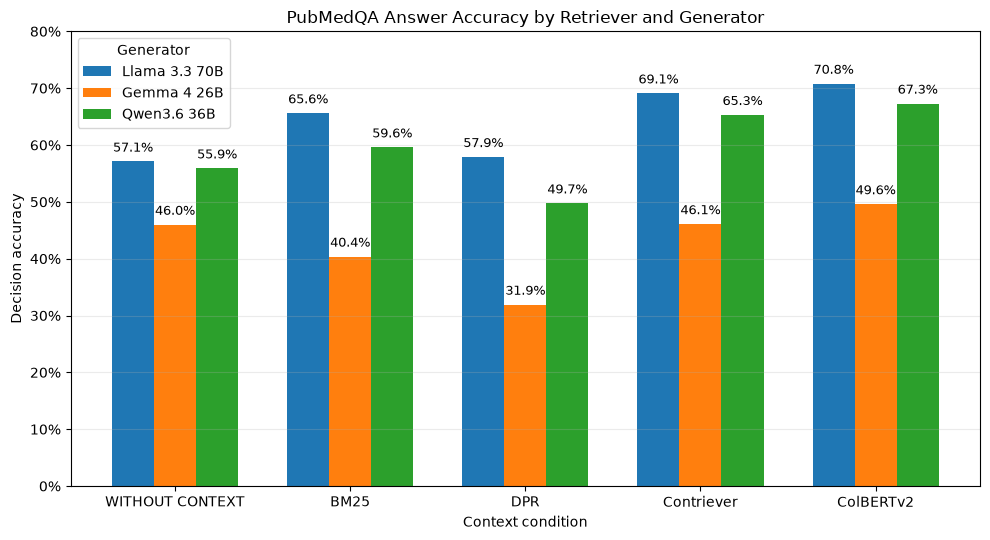

In [9]:
from matplotlib.ticker import PercentFormatter


# ------------------------------------------------------------
# Prepare accuracy values for plotting
# ------------------------------------------------------------

accuracy_plot = (
    correctness_summary
    .pivot(
        index="condition",
        columns="generator",
        values="Accuracy",
    )
    .reindex(
        CONDITION_ORDER
    )
)


# ------------------------------------------------------------
# Grouped bar chart
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 5.5)
)


x = np.arange(
    len(CONDITION_ORDER)
)

width = 0.24


for i, generator in enumerate(
    GENERATOR_ORDER
):

    values = (
        accuracy_plot[
            generator
        ]
        .astype(float)
        .to_numpy()
    )

    positions = (
        x
        + (i - 1) * width
    )

    bars = ax.bar(
        positions,
        values,
        width,
        label=generator,
    )


    # Show the exact accuracy above each bar
    for bar, value in zip(
        bars,
        values,
    ):

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            value + 0.012,
            f"{value:.1%}",
            ha="center",
            va="bottom",
            fontsize=9,
        )


# ------------------------------------------------------------
# Presentation
# ------------------------------------------------------------

ax.set_xticks(x)

ax.set_xticklabels(
    CONDITION_ORDER
)

ax.set_ylim(
    0,
    0.80,
)

ax.yaxis.set_major_formatter(
    PercentFormatter(
        1.0
    )
)

ax.set_ylabel(
    "Decision accuracy"
)

ax.set_xlabel(
    "Context condition"
)

ax.set_title(
    "PubMedQA Answer Accuracy by Retriever and Generator"
)

ax.legend(
    title="Generator",
)

ax.grid(
    axis="y",
    alpha=0.25,
)

fig.tight_layout()

plt.show()

## Does Retrieved Context Actually Help?

Absolute accuracy shows how each condition performs, but the main comparison should be made **question by question**.

For each generator and retriever, we compare:

**WITH CONTEXT − WITHOUT CONTEXT**

for the same PubMedQA question and the same language model.

This gives the change in decision accuracy caused by adding retrieved context.

- **Positive value:** retrieved context helped
- **Negative value:** retrieved context hurt
- **95% confidence interval includes zero:** the effect is not clearly resolved

We estimate the uncertainty using a **paired bootstrap with 10,000 resamples**.

This paired design is more reliable than comparing two independent averages because every question acts as its own control.

In [10]:
# ------------------------------------------------------------
# Paired bootstrap: WITH CONTEXT vs WITHOUT CONTEXT
# ------------------------------------------------------------

BOOTSTRAP_RESAMPLES = 10_000
BOOTSTRAP_SEED = 20260823


def paired_bootstrap_mean_difference(
    differences,
    *,
    n_resamples=BOOTSTRAP_RESAMPLES,
    seed=BOOTSTRAP_SEED,
    chunk_size=1000,
):
    """
    95% percentile bootstrap confidence interval
    for the mean paired difference.
    """
    differences = np.asarray(
        differences,
        dtype=float,
    )

    n = len(differences)

    if n == 0:
        raise ValueError(
            "No measurable paired observations."
        )

    rng = np.random.default_rng(
        seed
    )

    bootstrap_means = []

    remaining = n_resamples

    while remaining > 0:

        batch_size = min(
            chunk_size,
            remaining,
        )

        indices = rng.integers(
            0,
            n,
            size=(
                batch_size,
                n,
            ),
        )

        means = (
            differences[
                indices
            ]
            .mean(
                axis=1
            )
        )

        bootstrap_means.append(
            means
        )

        remaining -= batch_size


    bootstrap_means = np.concatenate(
        bootstrap_means
    )

    lower, upper = np.percentile(
        bootstrap_means,
        [
            2.5,
            97.5,
        ],
    )

    return (
        differences.mean(),
        lower,
        upper,
    )


# ------------------------------------------------------------
# Compare each retriever with WITHOUT CONTEXT
# ------------------------------------------------------------

context_effect_rows = []


for generator in GENERATOR_ORDER:

    baseline = (
        generation_scored[
            (
                generation_scored[
                    "generator"
                ]
                == generator
            )
            &
            (
                generation_scored[
                    "condition"
                ]
                == "WITHOUT CONTEXT"
            )
        ]
        [
            [
                "sample_id",
                "correct",
            ]
        ]
        .rename(
            columns={
                "correct":
                    "without_correct"
            }
        )
    )


    for condition in [
        "BM25",
        "DPR",
        "Contriever",
        "ColBERTv2",
    ]:

        with_context = (
            generation_scored[
                (
                    generation_scored[
                        "generator"
                    ]
                    == generator
                )
                &
                (
                    generation_scored[
                        "condition"
                    ]
                    == condition
                )
            ]
            [
                [
                    "sample_id",
                    "correct",
                ]
            ]
            .rename(
                columns={
                    "correct":
                        "with_correct"
                }
            )
        )


        paired = (
            baseline
            .merge(
                with_context,
                on="sample_id",
                how="inner",
                validate="one_to_one",
            )
            .dropna(
                subset=[
                    "without_correct",
                    "with_correct",
                ]
            )
        )


        differences = (
            paired[
                "with_correct"
            ]
            -
            paired[
                "without_correct"
            ]
        )


        mean_diff, ci_low, ci_high = (
            paired_bootstrap_mean_difference(
                differences
            )
        )


        if ci_low > 0:

            interpretation = (
                "Clear improvement"
            )

        elif ci_high < 0:

            interpretation = (
                "Clear degradation"
            )

        else:

            interpretation = (
                "Effect uncertain"
            )


        context_effect_rows.append(
            {
                "Generator":
                    generator,

                "Retriever":
                    condition,

                "Paired N":
                    len(paired),

                "Without accuracy":
                    paired[
                        "without_correct"
                    ].mean(),

                "With accuracy":
                    paired[
                        "with_correct"
                    ].mean(),

                "Effect":
                    mean_diff,

                "CI lower":
                    ci_low,

                "CI upper":
                    ci_high,

                "Interpretation":
                    interpretation,
            }
        )


context_effects = pd.DataFrame(
    context_effect_rows
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert len(
    context_effects
) == 12

assert (
    context_effects[
        "Paired N"
    ]
    > 0
).all()


# ------------------------------------------------------------
# Professor-facing table
# ------------------------------------------------------------

effect_display = (
    context_effects
    .copy()
)


for column in [
    "Without accuracy",
    "With accuracy",
    "Effect",
    "CI lower",
    "CI upper",
]:

    effect_display[
        column
    ] = (
        effect_display[
            column
        ]
        * 100
    )


print(
    "Paired context-effect analysis: PASS"
)

print()

display(
    effect_display.style.format(
        {
            "Without accuracy":
                "{:.1f}%",

            "With accuracy":
                "{:.1f}%",

            "Effect":
                "{:+.1f} pp",

            "CI lower":
                "{:+.1f} pp",

            "CI upper":
                "{:+.1f} pp",
        }
    )
)

print()
print(
    "Effect = WITH CONTEXT - WITHOUT CONTEXT"
)

print(
    "95% CI: paired bootstrap, "
    "10,000 resamples"
)

print(
    "LLM/API calls made by this cell: 0"
)

Paired context-effect analysis: PASS



,Generator,Retriever,Paired N,Without accuracy,With accuracy,Effect,CI lower,CI upper,Interpretation
0,Llama 3.3 70B,BM25,1000,57.1%,65.6%,+8.5 pp,+5.8 pp,+11.2 pp,Clear improvement
1,Llama 3.3 70B,DPR,1000,57.1%,57.9%,+0.8 pp,-2.4 pp,+4.0 pp,Effect uncertain
2,Llama 3.3 70B,Contriever,1000,57.1%,69.1%,+12.0 pp,+9.2 pp,+14.9 pp,Clear improvement
3,Llama 3.3 70B,ColBERTv2,1000,57.1%,70.8%,+13.7 pp,+10.8 pp,+16.6 pp,Clear improvement
4,Gemma 4 26B,BM25,996,45.9%,40.5%,-5.4 pp,-9.3 pp,-1.6 pp,Clear degradation
5,Gemma 4 26B,DPR,969,46.1%,32.0%,-14.1 pp,-18.3 pp,-10.0 pp,Clear degradation
6,Gemma 4 26B,Contriever,998,46.0%,46.1%,+0.1 pp,-3.7 pp,+4.1 pp,Effect uncertain
7,Gemma 4 26B,ColBERTv2,998,46.0%,49.6%,+3.6 pp,-0.3 pp,+7.6 pp,Effect uncertain
8,Qwen3.6 36B,BM25,1000,55.9%,59.6%,+3.7 pp,+0.3 pp,+7.1 pp,Clear improvement
9,Qwen3.6 36B,DPR,999,55.9%,49.7%,-6.1 pp,-9.9 pp,-2.2 pp,Clear degradation



Effect = WITH CONTEXT - WITHOUT CONTEXT
95% CI: paired bootstrap, 10,000 resamples
LLM/API calls made by this cell: 0


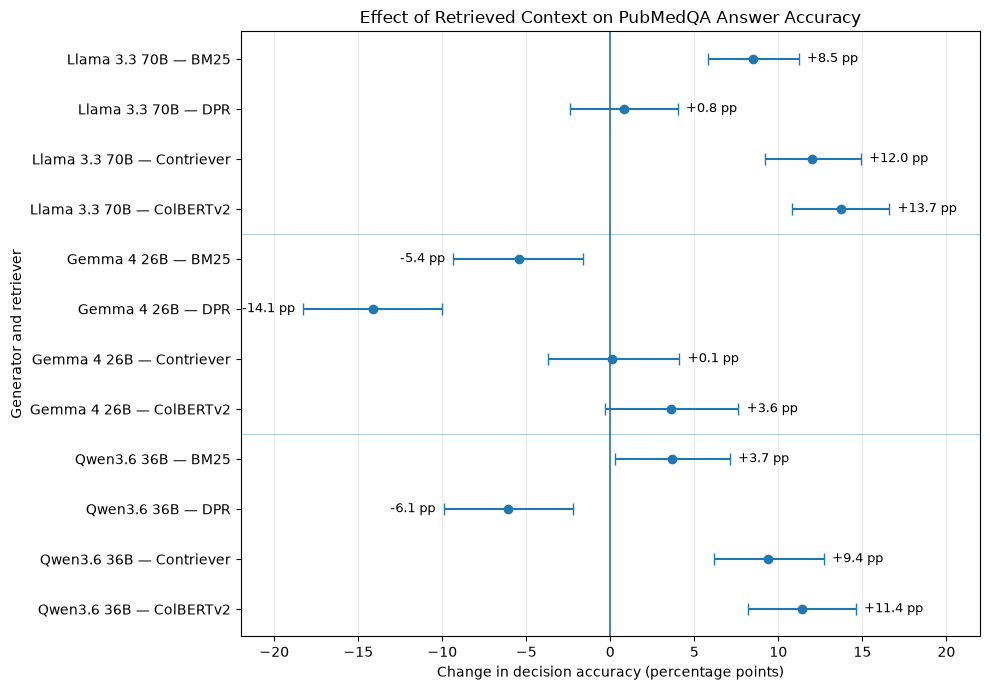

In [11]:
# ------------------------------------------------------------
# Main effect figure:
# WITH CONTEXT - WITHOUT CONTEXT
# ------------------------------------------------------------

effect_plot = context_effects.copy()


# Convert effects to percentage points
effect_plot["Effect_pp"] = (
    effect_plot["Effect"] * 100
)

effect_plot["CI_lower_pp"] = (
    effect_plot["CI lower"] * 100
)

effect_plot["CI_upper_pp"] = (
    effect_plot["CI upper"] * 100
)


# Keep the same logical order as the table
retriever_order = [
    "BM25",
    "DPR",
    "Contriever",
    "ColBERTv2",
]


effect_plot["Generator"] = pd.Categorical(
    effect_plot["Generator"],
    categories=GENERATOR_ORDER,
    ordered=True,
)

effect_plot["Retriever"] = pd.Categorical(
    effect_plot["Retriever"],
    categories=retriever_order,
    ordered=True,
)


effect_plot = (
    effect_plot
    .sort_values(
        [
            "Generator",
            "Retriever",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Labels and positions
# ------------------------------------------------------------

effect_plot["Label"] = (
    effect_plot["Generator"].astype(str)
    + " — "
    + effect_plot["Retriever"].astype(str)
)


y = np.arange(
    len(effect_plot)
)


means = (
    effect_plot["Effect_pp"]
    .to_numpy()
)

ci_lower = (
    effect_plot[
        "CI_lower_pp"
    ]
    .to_numpy()
)

ci_upper = (
    effect_plot[
        "CI_upper_pp"
    ]
    .to_numpy()
)


lower_error = (
    means
    - ci_lower
)

upper_error = (
    ci_upper
    - means
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 7)
)


ax.errorbar(
    means,
    y,
    xerr=[
        lower_error,
        upper_error,
    ],
    fmt="o",
    capsize=4,
    markersize=6,
)


# Zero means no change from adding context
ax.axvline(
    0,
    linewidth=1.2,
)


ax.set_yticks(y)

ax.set_yticklabels(
    effect_plot["Label"]
)

ax.invert_yaxis()


# Separate the three generator groups
ax.axhline(
    3.5,
    linewidth=0.8,
    alpha=0.35,
)

ax.axhline(
    7.5,
    linewidth=0.8,
    alpha=0.35,
)


ax.set_xlim(
    -22,
    22,
)


ax.set_xlabel(
    "Change in decision accuracy (percentage points)"
)

ax.set_ylabel(
    "Generator and retriever"
)

ax.set_title(
    "Effect of Retrieved Context on PubMedQA Answer Accuracy"
)


ax.grid(
    axis="x",
    alpha=0.25,
)


# ------------------------------------------------------------
# Put value labels outside the confidence intervals
# ------------------------------------------------------------

for i, value in enumerate(
    means
):

    if value >= 0:

        x_text = (
            ci_upper[i]
            + 0.5
        )

        alignment = "left"

    else:

        x_text = (
            ci_lower[i]
            - 0.5
        )

        alignment = "right"


    ax.text(
        x_text,
        i,
        f"{value:+.1f} pp",
        va="center",
        ha=alignment,
        fontsize=9,
    )


fig.tight_layout()

plt.show()

### Main Result

Retrieved context does **not** help every generator in the same way.

For **Llama 3.3 70B**, BM25, Contriever, and ColBERTv2 clearly improve decision accuracy. The largest improvement comes from ColBERTv2 at **+13.7 percentage points**.

For **Qwen3.6 36B**, Contriever and ColBERTv2 also give strong improvements, while DPR reduces accuracy by about **6.1 points**.

For **Gemma 4 26B**, the result depends strongly on the retriever. BM25 and DPR reduce accuracy, while the effects of Contriever and ColBERTv2 remain uncertain because their 95% confidence intervals include zero.

Overall, the baseline shows that **retrieved context is not automatically beneficial**.

Its effect depends on both:

**retrieval quality × generator behaviour**

## Does Better Retrieval Lead to Better Answers?

The previous sections show two things separately:

- how well each retriever finds relevant evidence;
- how accurately each language model answers the question.

Now we compare them.

For each retriever, we use its **full 1,000-question Recall@5** and compare it with the WITH_CONTEXT answer accuracy of each generator.

This helps us check whether stronger retrieval is associated with stronger final answers.

The comparison is descriptive:

**high retrieval quality does not automatically guarantee high answer accuracy.**

The final answer still depends on how well the language model uses the retrieved evidence.

In [12]:
# ------------------------------------------------------------
# Full-population retrieval quality
# ------------------------------------------------------------

full_retrieval_summary = (
    retrieval_per_query
    .groupby(
        "retriever",
        as_index=False,
    )
    .agg(
        Recall_at_5=(
            "recall_at_5",
            "mean",
        ),
        MRR_at_5=(
            "mrr_at_5",
            "mean",
        ),
        Recall_at_20=(
            "candidate_recall_at_20",
            "mean",
        ),
    )
)


# ------------------------------------------------------------
# WITH_CONTEXT answer accuracy
# ------------------------------------------------------------

answer_accuracy_summary = (
    correctness_summary[
        correctness_summary[
            "condition"
        ]
        != "WITHOUT CONTEXT"
    ]
    .copy()
)


condition_to_retriever = {
    "BM25": "bm25",
    "DPR": "dpr",
    "Contriever": "contriever",
    "ColBERTv2": "colbertv2",
}


answer_accuracy_summary[
    "retriever"
] = (
    answer_accuracy_summary[
        "condition"
    ]
    .astype(str)
    .map(
        condition_to_retriever
    )
)


# ------------------------------------------------------------
# Combine retrieval and answer quality
# ------------------------------------------------------------

retrieval_answer_summary = (
    answer_accuracy_summary[
        [
            "generator",
            "retriever",
            "Measured_N",
            "Accuracy",
        ]
    ]
    .rename(
        columns={
            "generator":
                "Generator",
            "Measured_N":
                "Measured N",
            "Accuracy":
                "Answer Accuracy",
        }
    )
    .merge(
        full_retrieval_summary,
        on="retriever",
        how="left",
        validate="many_to_one",
    )
)


retrieval_answer_summary[
    "Retriever"
] = (
    retrieval_answer_summary[
        "retriever"
    ]
    .map(
        RETRIEVER_DISPLAY
    )
)


retrieval_answer_summary = (
    retrieval_answer_summary[
        [
            "Generator",
            "Retriever",
            "Measured N",
            "Recall_at_5",
            "Answer Accuracy",
        ]
    ]
    .rename(
        columns={
            "Recall_at_5":
                "Recall@5",
        }
    )
)


# ------------------------------------------------------------
# Keep a clear presentation order
# ------------------------------------------------------------

retrieval_answer_summary[
    "Generator"
] = pd.Categorical(
    retrieval_answer_summary[
        "Generator"
    ],
    categories=GENERATOR_ORDER,
    ordered=True,
)

retrieval_answer_summary[
    "Retriever"
] = pd.Categorical(
    retrieval_answer_summary[
        "Retriever"
    ],
    categories=[
        "BM25",
        "DPR",
        "Contriever",
        "ColBERTv2",
    ],
    ordered=True,
)


retrieval_answer_summary = (
    retrieval_answer_summary
    .sort_values(
        [
            "Generator",
            "Retriever",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert len(
    retrieval_answer_summary
) == 12

assert (
    retrieval_answer_summary[
        "Recall@5"
    ]
    .notna()
    .all()
)

assert (
    retrieval_answer_summary[
        "Answer Accuracy"
    ]
    .notna()
    .all()
)


# ------------------------------------------------------------
# Professor-facing table
# ------------------------------------------------------------

print(
    "Retrieval-to-answer summary: PASS"
)

print()

display(
    retrieval_answer_summary.style.format(
        {
            "Recall@5":
                "{:.3f}",
            "Answer Accuracy":
                "{:.1%}",
        }
    )
)

print()
print(
    "Retrieval metrics use the full "
    "1,000-question retrieval evaluation."
)

print(
    "LLM/API calls made by this cell: 0"
)

Retrieval-to-answer summary: PASS



,Generator,Retriever,Measured N,Recall@5,Answer Accuracy
0,Llama 3.3 70B,BM25,1000,0.599,65.6%
1,Llama 3.3 70B,DPR,1000,0.325,57.9%
2,Llama 3.3 70B,Contriever,1000,0.740,69.1%
3,Llama 3.3 70B,ColBERTv2,1000,0.738,70.8%
4,Gemma 4 26B,BM25,998,0.599,40.4%
5,Gemma 4 26B,DPR,971,0.325,31.9%
6,Gemma 4 26B,Contriever,1000,0.740,46.1%
7,Gemma 4 26B,ColBERTv2,1000,0.738,49.6%
8,Qwen3.6 36B,BM25,1000,0.599,59.6%
9,Qwen3.6 36B,DPR,999,0.325,49.7%



Retrieval metrics use the full 1,000-question retrieval evaluation.
LLM/API calls made by this cell: 0


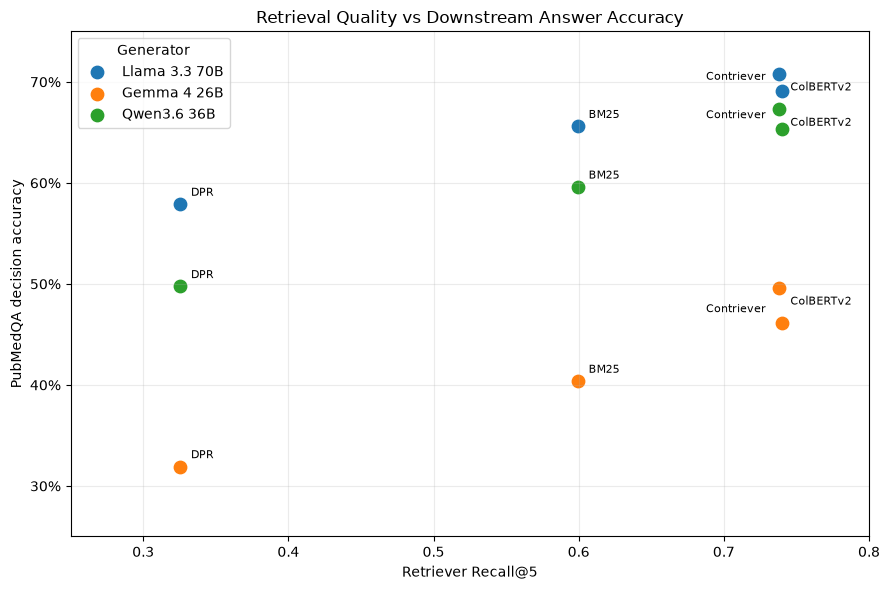

In [13]:
from matplotlib.ticker import PercentFormatter


# ------------------------------------------------------------
# Retrieval quality vs downstream answer accuracy
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 6)
)


for generator in GENERATOR_ORDER:

    subset = (
        retrieval_answer_summary[
            retrieval_answer_summary[
                "Generator"
            ]
            == generator
        ]
        .copy()
    )


    ax.scatter(
        subset["Recall@5"],
        subset["Answer Accuracy"],
        s=80,
        label=generator,
    )


    # Retriever labels
    for _, row in subset.iterrows():

        retriever = str(
            row["Retriever"]
        )

        # Small offsets keep the two strongest
        # retrievers from overlapping.
        if retriever == "Contriever":

            offset = (
                -55,
                8,
            )

        elif retriever == "ColBERTv2":

            offset = (
                8,
                -12,
            )

        else:

            offset = (
                8,
                6,
            )


        ax.annotate(
            retriever,
            (
                row["Recall@5"],
                row["Answer Accuracy"],
            ),
            xytext=offset,
            textcoords="offset points",
            fontsize=8,
        )


# ------------------------------------------------------------
# Presentation
# ------------------------------------------------------------

ax.set_xlim(
    0.25,
    0.80,
)

ax.set_ylim(
    0.25,
    0.75,
)


ax.yaxis.set_major_formatter(
    PercentFormatter(
        1.0
    )
)


ax.set_xlabel(
    "Retriever Recall@5"
)

ax.set_ylabel(
    "PubMedQA decision accuracy"
)

ax.set_title(
    "Retrieval Quality vs Downstream Answer Accuracy"
)


ax.legend(
    title="Generator"
)

ax.grid(
    alpha=0.25,
)


fig.tight_layout()

plt.show()

### Retrieval Quality and Answer Quality

Better retrieval is generally associated with better downstream answers, but the relationship is not one-to-one.

DPR has the lowest Recall@5 and also gives the weakest WITH_CONTEXT accuracy for all three generators.

Contriever and ColBERTv2 retrieve much stronger evidence and usually produce stronger final answers.

However, the same retrieved evidence still leads to different accuracies across Llama, Gemma, and Qwen.

This shows that:

**better retrieval provides better evidence opportunities, but the generator still determines how effectively that evidence is used.**

This comparison is descriptive and should not be interpreted as a causal analysis.

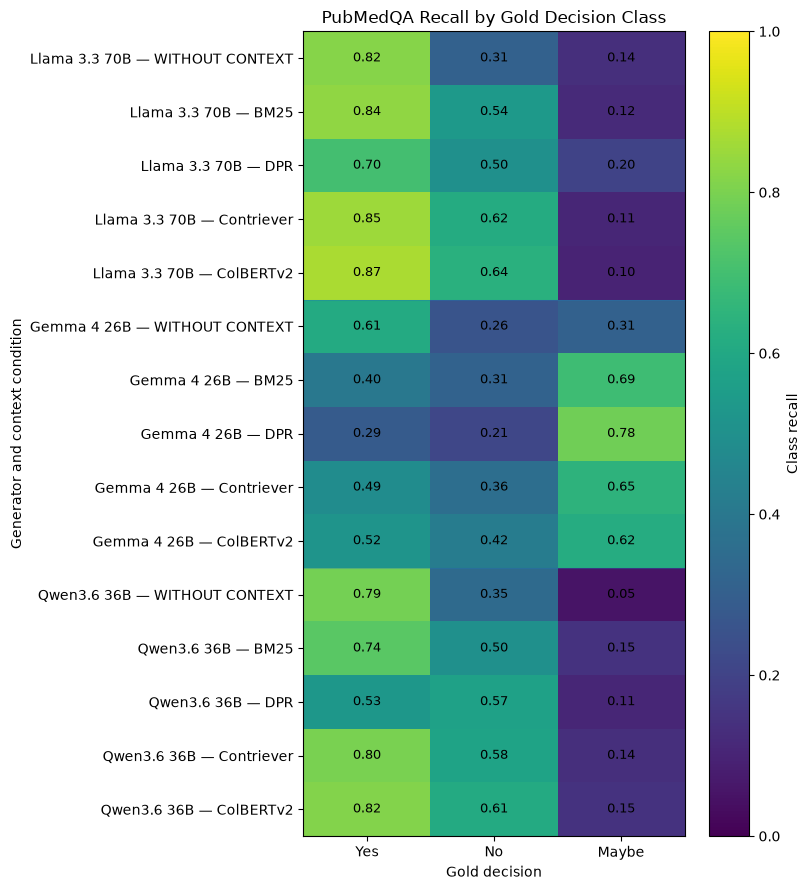

Class-level diagnostic: PASS
Primary metric remains overall decision accuracy.
LLM/API calls made by this cell: 0


In [14]:
# ------------------------------------------------------------
# Class-level diagnostic
# ------------------------------------------------------------

class_recall = (
    generation_scored
    .groupby(
        [
            "generator",
            "condition",
            "gold_decision",
        ],
        as_index=False,
    )
    .agg(
        Measured_N=(
            "correct",
            "count",
        ),
        Class_Recall=(
            "correct",
            "mean",
        ),
    )
)


# ------------------------------------------------------------
# Keep the presentation order fixed
# ------------------------------------------------------------

class_recall["generator"] = pd.Categorical(
    class_recall["generator"],
    categories=GENERATOR_ORDER,
    ordered=True,
)

class_recall["condition"] = pd.Categorical(
    class_recall["condition"],
    categories=CONDITION_ORDER,
    ordered=True,
)

class_recall["gold_decision"] = pd.Categorical(
    class_recall["gold_decision"],
    categories=[
        "yes",
        "no",
        "maybe",
    ],
    ordered=True,
)


class_recall = (
    class_recall
    .sort_values(
        [
            "generator",
            "condition",
            "gold_decision",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Heatmap table
# ------------------------------------------------------------

class_heatmap = (
    class_recall
    .assign(
        Row=lambda df:
            df["generator"].astype(str)
            + " — "
            + df["condition"].astype(str)
    )
    .pivot(
        index="Row",
        columns="gold_decision",
        values="Class_Recall",
    )
    .reindex(
        columns=[
            "yes",
            "no",
            "maybe",
        ]
    )
)


# Preserve the intended row order
expected_rows = [
    f"{generator} — {condition}"
    for generator in GENERATOR_ORDER
    for condition in CONDITION_ORDER
]

class_heatmap = (
    class_heatmap
    .reindex(
        expected_rows
    )
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 9)
)


image = ax.imshow(
    class_heatmap.to_numpy(),
    aspect="auto",
    vmin=0,
    vmax=1,
)


ax.set_xticks(
    np.arange(
        len(class_heatmap.columns)
    )
)

ax.set_xticklabels(
    [
        "Yes",
        "No",
        "Maybe",
    ]
)


ax.set_yticks(
    np.arange(
        len(class_heatmap.index)
    )
)

ax.set_yticklabels(
    class_heatmap.index
)


# Show the numeric recall value inside each cell
for i in range(
    class_heatmap.shape[0]
):

    for j in range(
        class_heatmap.shape[1]
    ):

        value = class_heatmap.iloc[
            i,
            j,
        ]

        if pd.notna(value):

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=9,
            )


# Separate the three generators
ax.axhline(
    4.5,
    linewidth=0.8,
    alpha=0.35,
)

ax.axhline(
    9.5,
    linewidth=0.8,
    alpha=0.35,
)


ax.set_title(
    "PubMedQA Recall by Gold Decision Class"
)

ax.set_xlabel(
    "Gold decision"
)

ax.set_ylabel(
    "Generator and context condition"
)


fig.colorbar(
    image,
    ax=ax,
    label="Class recall",
)


fig.tight_layout()

plt.show()


print(
    "Class-level diagnostic: PASS"
)

print(
    "Primary metric remains overall decision accuracy."
)

print(
    "LLM/API calls made by this cell: 0"
)

### Class-Level Diagnostic

The overall accuracy hides important differences between the three PubMedQA decision classes.

**Llama 3.3 70B** and **Qwen3.6 36B** perform best on `yes` questions and much worse on `maybe` questions.

**Gemma 4 26B** behaves differently. Its `yes` performance is lower, while its recall on `maybe` questions is much higher in several retrieval conditions.

The dataset is also imbalanced:

- `yes`: **552 questions**
- `no`: **338 questions**
- `maybe`: **110 questions**

Because `maybe` is the smallest class, these class-level results are treated as a diagnostic rather than the main evaluation.

The primary PubMedQA correctness metric remains **overall decision accuracy**.

## Metric Coverage in This Baseline

The project requires evaluation beyond answer accuracy, including faithfulness, coverage, retrieval diversity, and output change.

This notebook establishes the **non-diversified PubMedQA baseline**.

| Evaluation area | Status in this notebook |
|---|---|
| Retrieval effectiveness | **Complete** |
| Generation integrity | **Complete** |
| Answer correctness | **Complete** |
| Context vs no-context effect | **Complete** |
| Class-level diagnostics | **Complete** |
| Faithfulness / hallucination | Evaluated later |
| Retrieval diversity | Evaluated later |
| Answer-content change | Requires diversified answers |
| Diversity–accuracy trade-off | Requires diversified retrieval |
| Diversity–hallucination relationship | Requires diversified retrieval |

The saved baseline outputs will be reused in the later diversification experiments.

We therefore do **not** regenerate the 15,000 baseline answers.

## Main Findings

The PubMedQA baseline gives four clear findings.

### 1. Retrieval quality differs strongly

Contriever and ColBERTv2 have the highest Recall@5, while DPR retrieves much less relevant evidence.

### 2. Retrieved context is not always helpful

Llama and Qwen benefit strongly from Contriever and ColBERTv2.

However, DPR reduces Qwen accuracy and BM25/DPR reduce Gemma accuracy.

### 3. The generator matters

The same retriever can help one language model but hurt another.

This means RAG performance depends on both:

**retrieval quality × generator behaviour**

### 4. Strong retrieval is useful, but not sufficient

Better retrieval usually gives the model better evidence, but the final answer still depends on how well the generator uses that evidence.

This baseline therefore motivates the next stage of the project:

**Does diversification improve the evidence enough to increase answer quality, or does it introduce noise and hallucinations?**

In [15]:
# ------------------------------------------------------------
# Final notebook reproducibility audit
# ------------------------------------------------------------

audit_checks = []


def add_check(name, condition):
    condition = bool(condition)

    audit_checks.append(
        {
            "Check": name,
            "Status": (
                "PASS"
                if condition
                else "FAIL"
            ),
        }
    )

    if not condition:
        raise AssertionError(
            f"Notebook audit failed: {name}"
        )


# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

add_check(
    "PubMedQA questions = 1,000",
    len(dataset_rows) == 1000,
)

add_check(
    "Corpus passages = 3,358",
    corpus_manifest.document_count == 3358,
)

add_check(
    "Gold labels are yes / no / maybe",
    set(
        gold_df["gold_decision"]
    )
    == {
        "yes",
        "no",
        "maybe",
    },
)


# ------------------------------------------------------------
# Retrieval
# ------------------------------------------------------------

add_check(
    "Four retrievers available",
    set(
        retrieval_summary[
            "retriever"
        ]
    )
    == {
        "bm25",
        "dpr",
        "contriever",
        "colbertv2",
    },
)

add_check(
    "Retrieval rows = 4,000",
    len(
        retrieval_per_query
    )
    == 4000,
)


# ------------------------------------------------------------
# Generators and experimental matrix
# ------------------------------------------------------------

add_check(
    "Three admitted generators",
    len(
        model_validation
    )
    == 3,
)

add_check(
    "15 canonical generation conditions",
    len(
        canonical_runs
    )
    == 15,
)

add_check(
    "Generation artifacts = 15,000",
    len(
        generation_df
    )
    == 15000,
)

add_check(
    "Generation artifact IDs are unique",
    generation_df[
        "generation_artifact_id"
    ].nunique()
    == 15000,
)


# ------------------------------------------------------------
# Frozen generation-status totals
# ------------------------------------------------------------

expected_status_totals = {
    "OK": 14966,
    "PARSE_FAILURE": 33,
    "TRUNCATED": 1,
    "REFUSAL": 0,
    "ERROR": 0,
}


for status, expected_count in (
    expected_status_totals.items()
):

    add_check(
        f"{status} outputs = {expected_count:,}",
        int(
            status_totals[
                status
            ]
        )
        == expected_count,
    )


# ------------------------------------------------------------
# Evaluation outputs
# ------------------------------------------------------------

add_check(
    "15 correctness conditions",
    len(
        correctness_summary
    )
    == 15,
)

add_check(
    "12 paired context comparisons",
    len(
        context_effects
    )
    == 12,
)

add_check(
    "12 retrieval-to-answer rows",
    len(
        retrieval_answer_summary
    )
    == 12,
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

audit_table = pd.DataFrame(
    audit_checks
)


print(
    "FINAL NOTEBOOK AUDIT"
)

print()

display(
    audit_table
)

print()

print(
    "All required baseline checks: PASS"
)

print(
    "Saved experimental artifacts were reused."
)

print(
    "No retrieval or LLM generation was rerun."
)

print(
    "LLM/API calls made by this cell: 0"
)

FINAL NOTEBOOK AUDIT



,Check,Status
0,"PubMedQA questions = 1,000",PASS
1,"Corpus passages = 3,358",PASS
2,Gold labels are yes / no / maybe,PASS
3,Four retrievers available,PASS
4,"Retrieval rows = 4,000",PASS
5,Three admitted generators,PASS
6,15 canonical generation conditions,PASS
7,"Generation artifacts = 15,000",PASS
8,Generation artifact IDs are unique,PASS
9,"OK outputs = 14,966",PASS



All required baseline checks: PASS
Saved experimental artifacts were reused.
No retrieval or LLM generation was rerun.
LLM/API calls made by this cell: 0


## Limitations and Next Steps

This notebook establishes the **non-diversified PubMedQA baseline**.

### Limitations

- PubMedQA measures a three-class decision (`yes`, `no`, `maybe`), so it does not test long-form multi-aspect answering.
- Retrieval quality and answer accuracy are related, but the analysis here does not prove a causal relationship between them.
- The confidence intervals shown for the context effects are ordinary paired-bootstrap intervals and are not multiplicity-adjusted confirmatory tests.
- Faithfulness, hallucination, retrieval diversity, and answer-content change are not yet evaluated in this baseline notebook.
- PubMedQA is used as a historical-observed control replication, not as protected-final evidence.

### Next steps

The next experiment adds diversity-aware retrieval using:

- MMR
- K-Means selection
- Agglomerative clustering
- DPP selection

The diversified Top-5 context will then be compared with the relevance-only Top-5 baseline.

The later evaluation will measure:

1. **Retrieval effectiveness**
2. **Retrieval diversity**
3. **Answer correctness**
4. **Faithfulness / hallucination**
5. **Answer-content change**

The same evaluation structure will also be applied to **HotpotQA** and **ASQA** using the appropriate dataset-specific metrics.

The final goal is to answer:

> **Does diversifying retrieved context improve LLM reasoning, or does it introduce noise and hallucinations?**

## Reproducibility

This notebook is designed to run from top to bottom using the saved project artifacts.

Running **Restart Kernel → Run All Cells** will:

- load the frozen PubMedQA dataset revision;
- validate the saved manifests and experimental artifacts;
- load the historical retrieval results;
- load the 15,000 saved LLM generations;
- recompute the reported tables, figures, and statistical analysis;
- make **zero LLM/API calls**.

It will **not**:

- rerun retrieval;
- rebuild indexes;
- regenerate LLM answers;
- repair failed model outputs;
- overwrite the original generation evidence.

The notebook therefore reproduces the analysis while keeping the expensive experimental evidence immutable.